In [1]:
from __future__ import annotations

import sys, os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import time
import tkinter
import pathlib
import pickle
import tifffile
import os
import numpy as np
from PIL import (Image, ImageTk, ImageDraw)
from tkinter import filedialog, messagebox
from matplotlib.figure import Figure 
from matplotlib.backends.backend_tkagg import (FigureCanvasTkAgg, NavigationToolbar2Tk)
from matplotlib.patches import Rectangle, Circle
from matplotlib.backend_bases import MouseEvent
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.pyplot as plt
from skimage import measure
import fishCore
import fishGUI
import threading
import concurrent.futures
import cv2
import imageio.v3 as iio
import napari
from aicsimageio import AICSImage

f = fishCore.Fish(pathlib.Path("./config.ini"))
f.set_model_version("3.50")

c:\Users\msgal\Downloads\Ding_Lab\FISH-ML_multichannel\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


final text_encoder_type: bert-base-uncased


[2025-10-27 00:53:57,417][INFO] CHECK: Model version 3.50 loaded


Cyt shape: (2048, 2048)
Nuc shape: (2048, 2048)


(-0.5, 2047.5, 2047.5, -0.5)

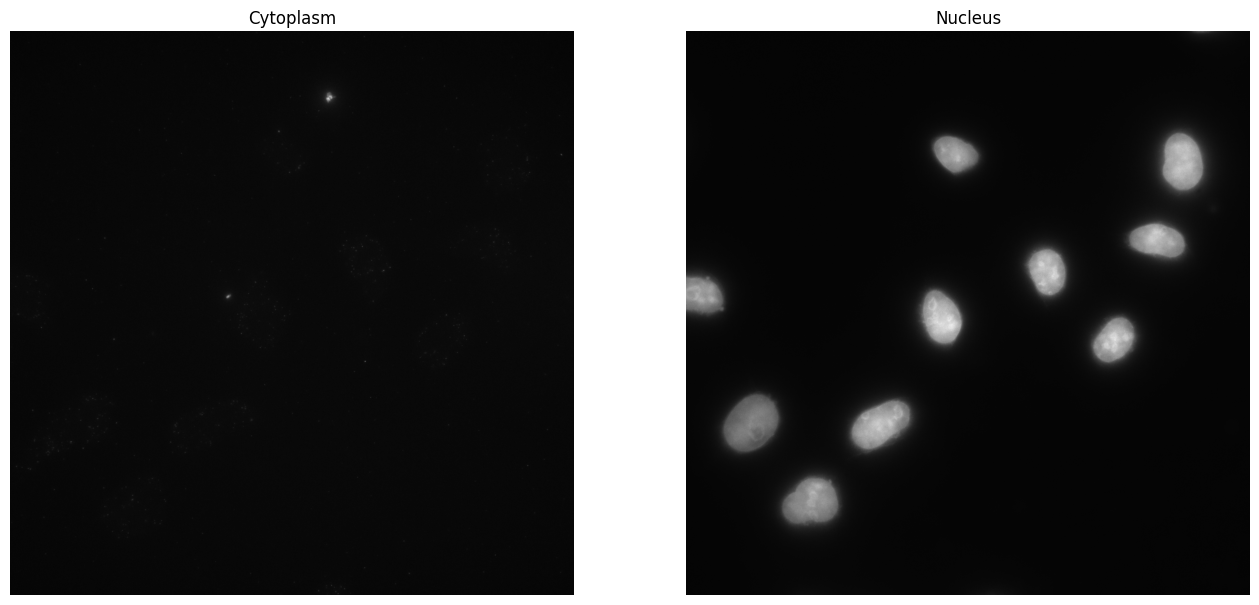

In [ ]:
import tifffile
import matplotlib.pyplot as plt

cyt_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML_MULTICHANNEL/B2 _Z-PROJECTED/MAX_AD_33_B2_w4-594_s001.tif"
nuc_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML_MULTICHANNEL/B2 _Z-PROJECTED/MAX_AD_33_B2_w1-DAPI_s001.tif"

cyt_img = tifffile.imread(cyt_path)
nuc_img = tifffile.imread(nuc_path)

print(f"Cyt shape: {cyt_img.shape}")
print(f"Nuc shape: {cyt_img.shape}")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

ax[0].imshow(cyt_img, cmap='gray')
ax[0].set_title("Cytoplasm")
ax[0].axis('off')

ax[1].imshow(nuc_img, cmap='gray')
ax[1].set_title("Nucleus")
ax[1].axis('off')


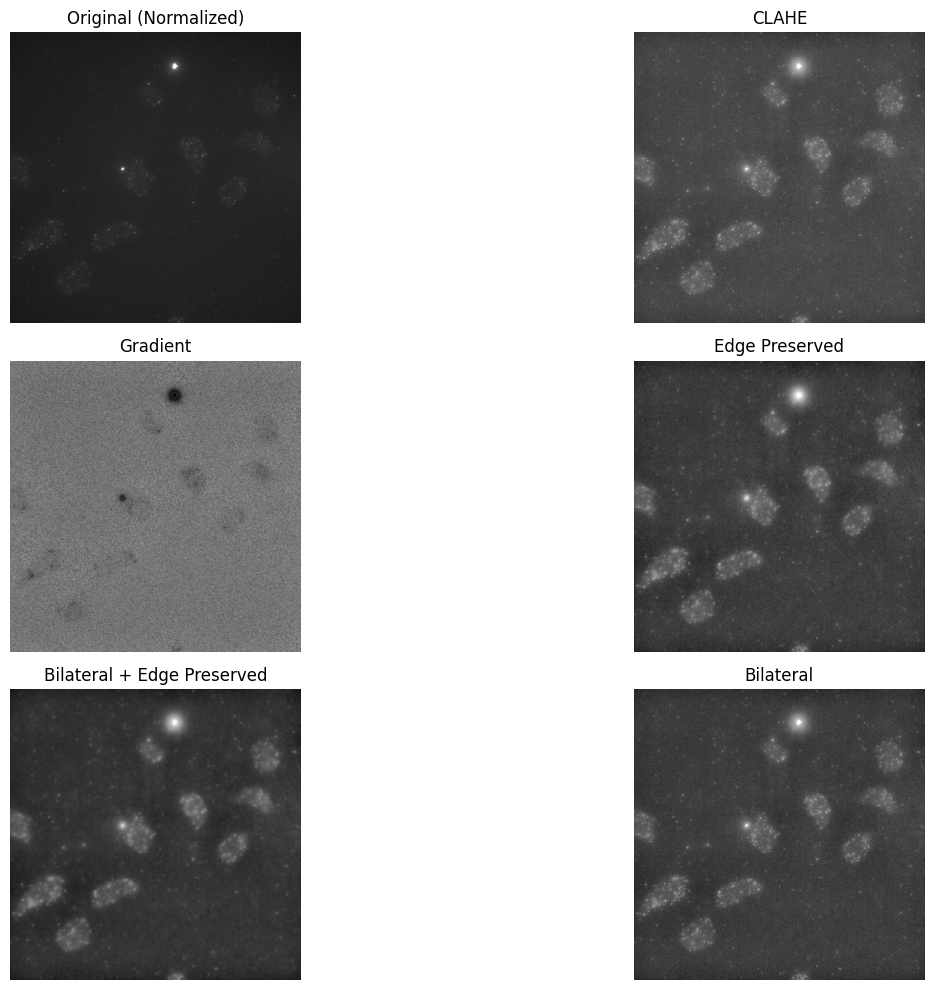

In [3]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from math import log
from skimage import exposure
import pathlib
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)

# --------------------------------------
# Helper functions
# --------------------------------------
def remove_outliers(img, k=20.0, use_median=False):
    """
    Clip values that are more than k std-dev (or MAD units) above center.
    Args:
        img: 16-bit numpy array
        k: threshold (e.g. 3σ)
        use_median: if True use median+MAD, else mean+std
    Returns:
        clipped float32 image in [0,1]
    """
    x = img.astype(np.float32)

    mean = np.mean(x)
    std = np.std(x)
    thresh = mean + k * std

    # clip outliers
    x_clipped = np.minimum(x, thresh)

    # normalize after clipping (to 0..1)
    x_norm = (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min() + 1e-6)
    return x_norm

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def calculate_sigma(img):
    # ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
    print(f'Estimated Gaussian noise standard deviation = {estimate_sigma(img)}')
    sig = estimate_sigma(img, channel_axis=None, average_sigmas=True)
    return sig

def apply_clahe(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def laplacian(img, cyt_bilat):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)
    cyt_blended = cv2.addWeighted(cyt_bilat, 0.8, lap, 0.2, 0)
    return cyt_blended

def gradient(channel, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.morphologyEx(channel, cv2.MORPH_GRADIENT, kernel)

# --------------------------------------
# Load image and preprocess
# --------------------------------------

# ----- NON COMPOSITE IMAGES -----
cyt_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML_MULTICHANNEL/B2 _Z-PROJECTED/MAX_AD_33_B2_w4-594_s001.tif"
nuc_path = "C:/Users/msgal/Downloads/Ding_Lab/FISH-ML_MULTICHANNEL/B2 _Z-PROJECTED/MAX_AD_33_B2_w1-DAPI_s001.tif"

with tifffile.TiffFile(cyt_path) as tif:
    cyt = tif.pages[0].asarray() # testing with 488

with tifffile.TiffFile(nuc_path) as tif:
    nucleus = tif.pages[0].asarray()

cyt_removed = remove_outliers(cyt)
cyt_norm = normalize_to_uint8(cyt_removed)

sigma_est = estimate_sigma(cyt_norm, channel_axis=-1, average_sigmas=True)
clahe = apply_clahe(cyt_norm)
grad = gradient(clahe)
# gaussian = cv2.GaussianBlur(clahe, (0,0), 1.0)   

# contrast_factor = 1.5  # Greater than 1 for increased contrast
# brightness_offset = 1   # Adjust brightness (optional)
# enhanced = cv2.addWeighted(clahe, contrast_factor, np.zeros(clahe.shape, clahe.dtype), 0, brightness_offset)

sigma_est = estimate_sigma(clahe, channel_axis=-1, average_sigmas=True)

sigma_norm = sigma_est + 3.0
sigma_weak = (sigma_est - 10.0) if (sigma_est - 10.0) > 0 else 0

bilat1 = cv2.bilateralFilter(clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
edge_preserved = cv2.edgePreservingFilter(clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)
bilat_edge = cv2.edgePreservingFilter(bilat1, flags=1, sigma_s=sigma_weak, sigma_r=0.4)
blended = laplacian(cyt_norm, bilat1)

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

ax[0, 0].imshow(cyt_norm, cmap='gray')
ax[0, 0].set_title("Original (Normalized)")
ax[0, 0].axis('off')

ax[0, 1].imshow(clahe, cmap='gray')
ax[0, 1].set_title("CLAHE")
ax[0, 1].axis('off')


ax[1, 0].imshow(grad, cmap='gray')
ax[1, 0].set_title("Gradient")
ax[1, 0].axis('off')

ax[1, 1].imshow(edge_preserved, cmap='gray')
ax[1, 1].set_title("Edge Preserved")
ax[1, 1].axis('off')

ax[2, 0].imshow(bilat_edge, cmap='gray')
ax[2, 0].set_title("Bilateral + Edge Preserved")
ax[2, 0].axis('off')

ax[2, 1].imshow(bilat1, cmap='gray')
ax[2, 1].set_title("Bilateral")
ax[2, 1].axis('off')

# ax[3, 0].imshow(blended, cmap='gray')
# ax[3, 0].set_title("Blended")
# ax[3, 0].axis('off')


fig.tight_layout()

plt.show()